In [2]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy

from phentax.waveform import IMRPhenomTHM
from phentax.waveform_tf import IMRPhenomTHM_TF
from phentax.utils.time_frequency import setup_tf_grid

FIGSIZE = (10, 6)

## Phentax time-frequency tutorial

In [3]:
# Parameters for a test case
m1 = 5e6
m2 = 1e6
chi1 = 0.9
chi2 = 0.7
distance = 500.0
inclination = jnp.pi / 3.0
phi_ref = 0.0
psi = 0.0
f_ref = 5e-5
f_min = f_ref
delta_t = 5

In [4]:
settings = dict(
    higher_modes="all",
    include_negative_modes=True,
    t_low_fit=True,
    coarse_grain=False,
    atol=1e-12,
    rtol=1e-12,
)

imr = IMRPhenomTHM(**settings)
imr_tf = IMRPhenomTHM_TF(**settings)

#### Time-domain waveform

In [5]:
times, mask, h_plus, h_cross = imr.compute_polarizations_at_once(
    m1,
    m2,
    chi1,
    chi2,
    distance,
    phi_ref,
    inclination,
    psi,
    delta_t=delta_t,
    f_min=f_min,
    f_ref=f_ref,
)

# shift times to start at zero
t = times.squeeze() - times.squeeze()[0]
keep = t > 0
t = t[keep]
h_plus = h_plus.squeeze()[keep]

tc = t[np.argmax(h_plus)]

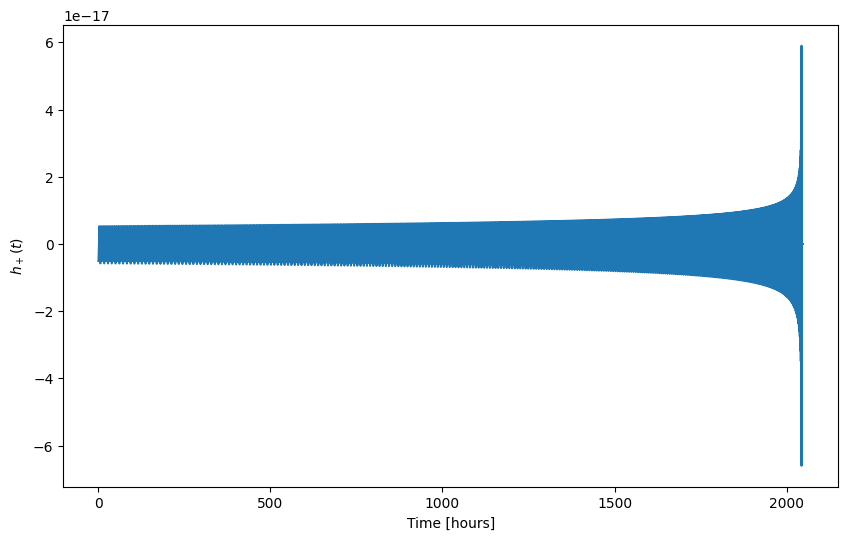

In [6]:
plt.figure(figsize=FIGSIZE)
plt.plot(t[::10] / 3600, h_plus[::10])
plt.xlabel("Time [hours]")
plt.ylabel(r"$h_+(t)$")
plt.show()

#### Brute-force SFT

Tukey-windowed FFT of $h_+(t)$ on 1-day segments. This is the reference the Fresnel waveforms should reproduce.

In [7]:
t_grid, f_grid = setup_tf_grid(T=t[-1], dt=delta_t, dT=24 * 3600)
n_segs = t_grid.shape[0] - 1

h_sft = np.zeros((n_segs, f_grid.shape[0]), dtype=complex)
for i in range(n_segs):

    sel = (t >= t_grid[i]) & (t < t_grid[i + 1])
    
    ## Apply a Tukey window to the segment to reduce spectral leakage
    win = scipy.signal.windows.tukey(np.sum(sel), alpha=0.2)

    h_sft[i] = (np.fft.rfft(h_plus[sel] * win) * delta_t)[1:]

Setting up time-frequency grid...
Total observation time: 7371636.472842924 s
Number of time segments: 85
NOTE: The time grid calculates the number of segments as int(T/dT), which means it rounds down the number of segments.


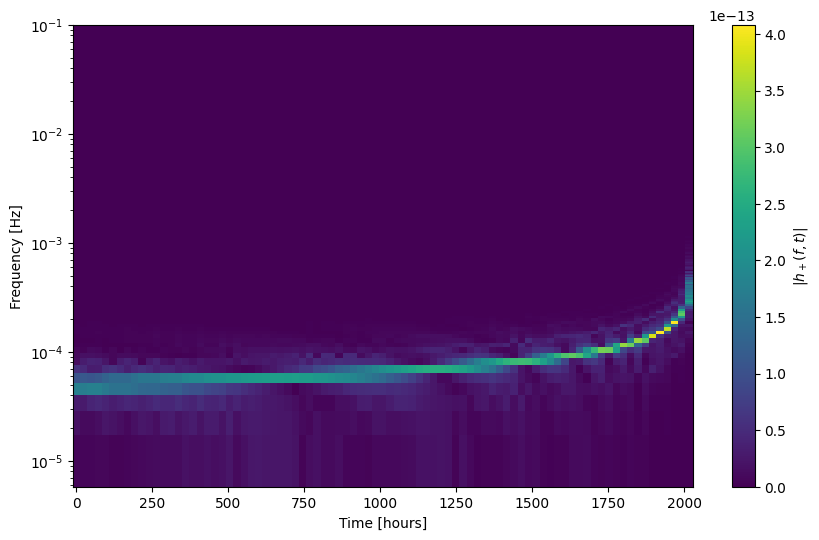

In [8]:
def plot_tf(h, label=r"$|h_+(f,t)|$"):
    plt.figure(figsize=FIGSIZE)
    plt.pcolormesh(t_grid[:-1] / 3600, f_grid, np.abs(h).T, shading="auto")
    plt.semilogy()
    plt.colorbar(label=label)
    plt.xlabel("Time [hours]")
    plt.ylabel("Frequency [Hz]")
    plt.show()

plot_tf(h_sft)

#### Fresnel TF waveforms

- Generated directly on the TF grid, for a batch of `N_batch` sources. Outputs are `(h_plus, h_cross)`, each of shape `(N_batch, n_times, n_freqs)`.

In [9]:
N_batch = 100

params = dict(
    m1=jnp.full(N_batch, m1),
    m2=jnp.full(N_batch, m2),
    chi1z=jnp.full(N_batch, chi1),
    chi2z=jnp.full(N_batch, chi2),
    distance=jnp.full(N_batch, distance),
    phi_ref=jnp.full(N_batch, phi_ref),
    f_ref=f_ref,
    f_min=f_min,
    inclination=jnp.full(N_batch, inclination),
    psi=jnp.full(N_batch, psi),
)

- Initially generating the 'Vanilla' Fresnel which corresponds to a box-car window, i.e. there is a window mismodelling here between the ground-truth SFT and the model. Here the waveform parameters are defined at the beginning of each SFT segment too. This implementation is written inside the time-frequency class for readability and understanding/intuition, in practice the tukey variant described below is almost always better. 


/data/diganta/THM_TF/venv/lib/python3.12/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


Shape: (100, 86, 8640), memory: 1133.8 MB


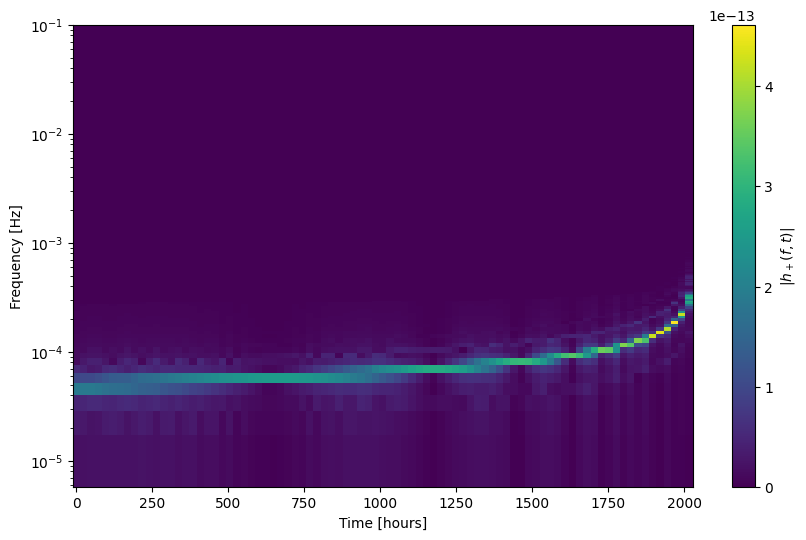

In [10]:
tf_vanilla = imr_tf.get_tf_fresnel_waveform_vanilla_TF(
    t_grid, f_grid, **params, delta_t=delta_t, closest_f_bins=20
)
h_vanilla = tf_vanilla[0][0]

print(f"Shape: {tf_vanilla[0].shape}, memory: {tf_vanilla[0].nbytes / 1024**2:.1f} MB")
plot_tf(h_vanilla)

- Fresnel taking into account of the tukey window, and defining waveform parameters at the centre of each SFT segment, resulting in a more accurate representation of the time-frequency waveform.

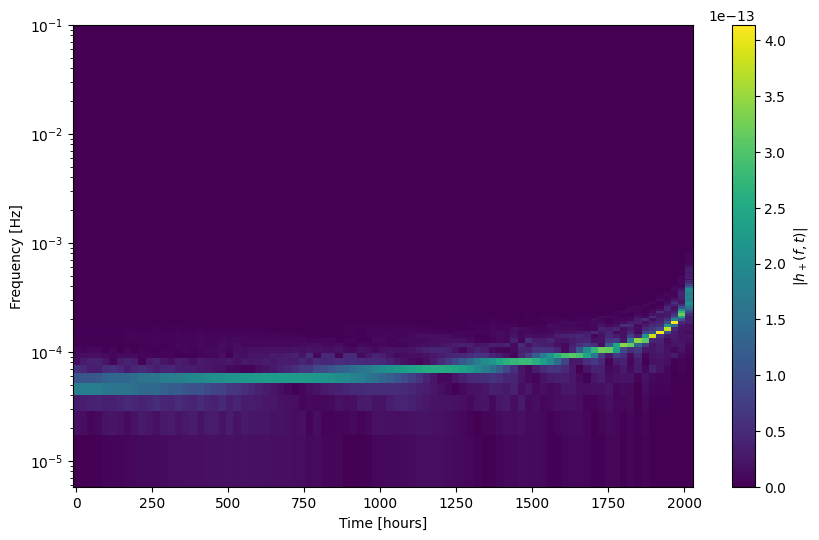

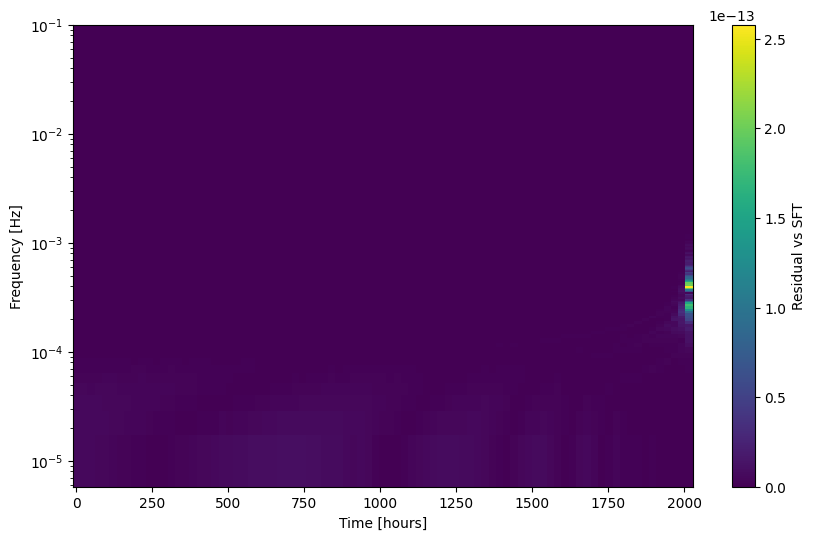

In [11]:
tf_tukey = imr_tf.get_tf_fresnel_tukey_midpoint(
    t_grid, f_grid, **params, tukey_alpha=0.2, closest_f_bins=20
)
h_tukey = tf_tukey[0][0]

plot_tf(h_tukey)
plot_tf(h_tukey - h_sft, label="Residual vs SFT")

In [17]:
h_vanilla.shape, h_tukey.shape, h_sft.shape

((85, 8640), (85, 8640), (85, 8640))

#### Comparison against the SFT

In [21]:
def match(a, b, axis=None):
    ''''
    Flat PSD match 
    '''

    inner = np.real(np.sum(a * np.conj(b), axis=axis))
    return inner / np.sqrt(np.sum(np.abs(a) ** 2, axis=axis) * np.sum(np.abs(b) ** 2, axis=axis))

def cumulative_match(a, b):
    ''''
    Match as a function of time, with flat PSD. 

    Cumulative in the sense that it considers the match of the waveform segments up to a given time, rather than just the instantaneous match at that time. This is useful for analyzing how well two waveforms agree over the course of their evolution.
    Closest quantity to data analysis, as it considers all the signal upto some time t. 
    '''
    inner = np.cumsum(np.real(np.sum(a * np.conj(b), axis=1)))
    return inner / np.sqrt(np.cumsum(np.sum(np.abs(a) ** 2, axis=1)) * np.cumsum(np.sum(np.abs(b) ** 2, axis=1)))



h_vanilla, h_tukey = np.asarray(h_vanilla), np.asarray(h_tukey)

print(f"Final total match (vanilla) vs SFT: {match(h_vanilla, h_sft):.6f}, at worst 24 hours before merger.")
print(f"Final total match (tukey) vs SFT: {match(h_tukey, h_sft):.6f}, at worst 24 hours before merger.")

Final total match (vanilla) vs SFT: 0.907903, at worst 24 hours before merger.
Final total match (tukey) vs SFT: 0.967979, at worst 24 hours before merger.


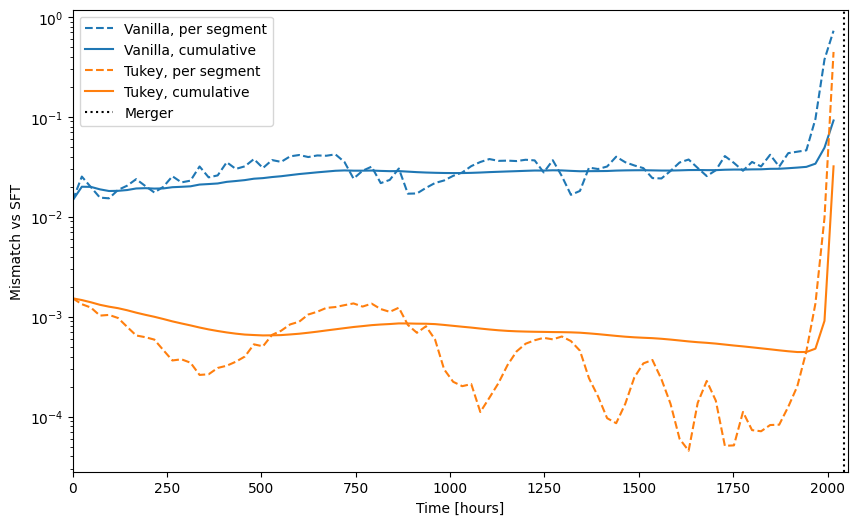

In [ ]:
t_hours = t_grid[:-1] / 3600

fig, ax = plt.subplots(figsize=FIGSIZE)
for h, name in ((h_vanilla, "Vanilla"), (h_tukey, "Tukey")):
    line, = ax.plot(t_hours, 1 - match(h, h_sft, axis=1), ls="--", label=f"{name}, per segment")
    ax.plot(t_hours, 1 - cumulative_match(h, h_sft), color=line.get_color(), label=f"{name}, cumulative")
ax.axvline(tc / 3600, color="k", ls=":", label="Merger")
ax.semilogy()
ax.set_xlim(t_hours[0], tc / 3600 + 0.005 * t_grid[-1] / 3600)
ax.set_xlabel("Time [hours]")
ax.set_ylabel("Mismatch vs SFT")
ax.legend()
plt.show()

#### Perturbed batch

Each source in the batch gets slightly different masses and spins. Shapes are unchanged, no recompilation, speed is retained.

In [14]:
key = jax.random.PRNGKey(0)
u = jax.random.uniform(key, (4, N_batch))

params_pert = dict(
    params,
    m1=params["m1"] * (1 + 0.2 * u[0]),
    m2=params["m2"] * (1 + 0.2 * u[1]),
    chi1z=params["chi1z"] * (1 - 0.2 * u[2]),
    chi2z=params["chi2z"] * (1 - 0.2 * u[3]),
)

tf_pert = imr_tf.get_tf_fresnel_tukey_midpoint(
    t_grid, f_grid, **params_pert, tukey_alpha=0.2, closest_f_bins=20
)
h_pert = np.asarray(tf_pert[0])  # (N_batch, n_times, n_freqs)


Match between perturbed sources 0 and 1: 0.014405, shows they are different sources


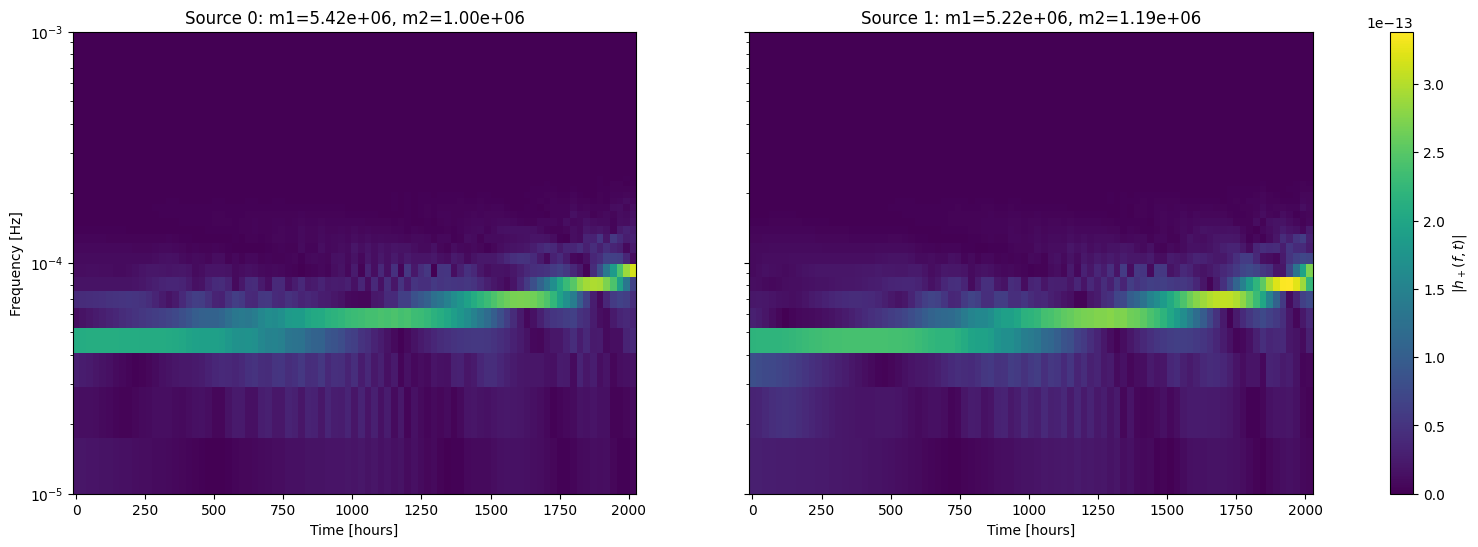

In [16]:
i, j = 0, 1
vmax = np.abs(h_pert[[i, j]]).max()

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(2 * FIGSIZE[0], FIGSIZE[1]))
for ax, k in zip(axs, (i, j)):
    mesh = ax.pcolormesh(t_hours, f_grid, np.abs(h_pert[k]).T, shading="auto", vmin=0, vmax=vmax)
    ax.set_yscale("log")
    ax.set_ylim(1e-5, 1e-3)
    ax.set_title(f"Source {k}: m1={float(params_pert['m1'][k]):.2e}, m2={float(params_pert['m2'][k]):.2e}")
    ax.set_xlabel("Time [hours]")
axs[0].set_ylabel("Frequency [Hz]")
fig.colorbar(mesh, ax=axs, label=r"$|h_+(f,t)|$")
match_perturbed = match(h_pert[i], h_pert[j])
print(f"Match between perturbed sources {i} and {j}: {match_perturbed:.6f}, shows they are different sources")
plt.show()

#### Timing

In [31]:
%%timeit
jax.block_until_ready(imr_tf.get_tf_fresnel_waveform_vanilla_TF(
    t_grid, f_grid, **params, delta_t=delta_t, closest_f_bins=20
))

22.3 ms ± 31.9 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [32]:
%%timeit
jax.block_until_ready(imr_tf.get_tf_fresnel_tukey_midpoint(
    t_grid, f_grid, **params, tukey_alpha=0.2, closest_f_bins=20
))

17 ms ± 70.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Perturbed batch:

In [33]:
%%timeit
jax.block_until_ready(imr_tf.get_tf_fresnel_tukey_midpoint(
    t_grid, f_grid, **params_pert, tukey_alpha=0.2, closest_f_bins=20
))

19.4 ms ± 192 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
